# 🔥 PyTorch — Hands On

| Chapter | Topic |
|---|---|
| **0** | Setup |
| **1** | MNIST — build a network from scratch |
| **2** | Titanic — same tools, messy data |
| **3** | Wrap-up |

**🧩 = fill in the blanks** &nbsp;•&nbsp; **🔬 = change the numbers and re-run** &nbsp;•&nbsp; **❓ = discuss**

Run every cell in order, top to bottom.

---
# 📦 Chapter 0 — Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Using device:  ", device)

PyTorch version: 2.11.0+cu128
Using device:   cuda


---
# 🔢 Chapter 1 — MNIST

## 1.1 — Load the data

In [ ]:
from torchvision import datasets

mnist_train = datasets.MNIST(root="./data", train=True,  download=True)
mnist_test  = datasets.MNIST(root="./data", train=False, download=True)

print("Train images:", mnist_train.data.shape)
print("Train labels:", mnist_train.targets.shape)
print("Test images: ", mnist_test.data.shape)
print("\nPixel value range:", mnist_train.data.min().item(), "to", mnist_train.data.max().item())
print("Pixel dtype:      ", mnist_train.data.dtype)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]

Train images: torch.Size([60000, 28, 28])
Train labels: torch.Size([60000])
Test images:  torch.Size([10000, 28, 28])

Pixel value range: 0 to 255
Pixel dtype:       torch.uint8


✅ `[60000, 28, 28]` • `[60000]` • `[10000, 28, 28]` • range `0 to 255` • dtype `uint8`

## 1.2 — Look at the data

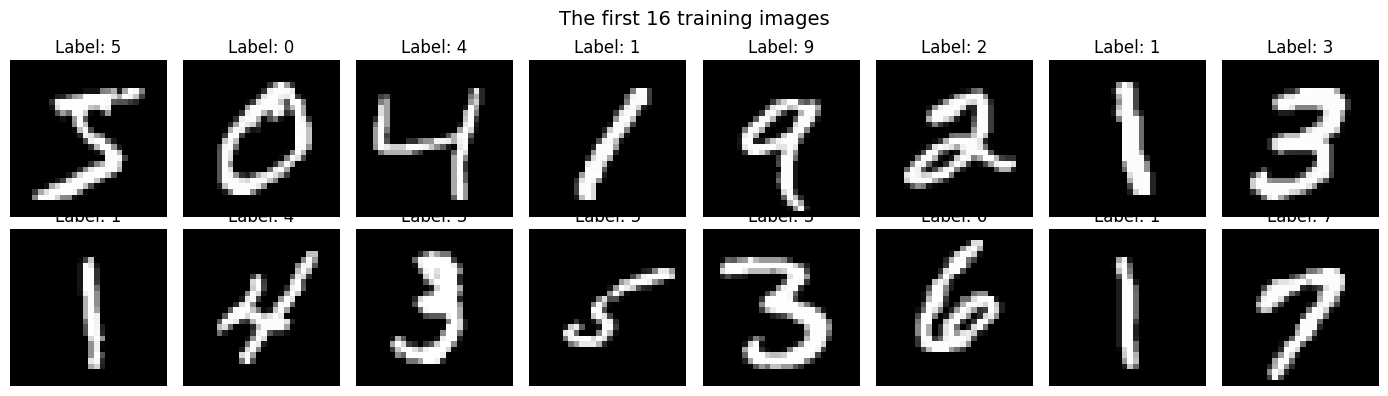

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(mnist_train.data[i], cmap="gray")
    ax.set_title(f"Label: {mnist_train.targets[i].item()}")
    ax.axis("off")
plt.suptitle("The first 16 training images", fontsize=14)
plt.tight_layout()
plt.show()

### Is the dataset balanced?

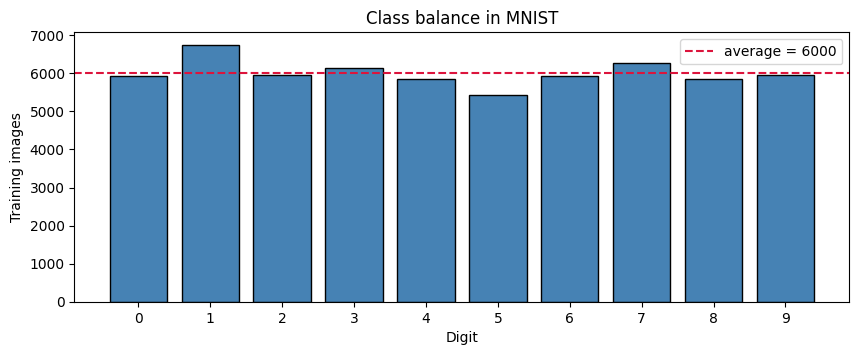

Always-guess-the-most-common-digit accuracy: 11.24%


In [ ]:
counts = torch.bincount(mnist_train.targets)

plt.figure(figsize=(10, 3.5))
plt.bar(range(10), counts.numpy(), color="steelblue", edgecolor="black")
plt.axhline(counts.float().mean().item(), color="crimson", linestyle="--",
            label=f"average = {counts.float().mean().item():.0f}")
plt.xticks(range(10)); plt.xlabel("Digit"); plt.ylabel("Training images")
plt.title("Class balance in MNIST"); plt.legend(); plt.show()

print(f"Always-guess-the-most-common-digit accuracy: {counts.max().item() / len(mnist_train):.2%}")

## 1.3 — Flatten the images 🧩

💡 `.view(-1, N)` = "reshape into N columns, work out the rows yourself". `28 × 28 = 784`.

In [ ]:
# 🧩 FILL IN THE BLANKS

X_train = mnist_train.data.float().view(-1,784) / 255
y_train = mnist_train.targets

X_test  = mnist_test.data.float().view(-1, 784) / 255
y_test  = mnist_test.targets

print("Before:", mnist_train.data.shape)
print("After: ", X_train.shape)
print("New pixel range:", X_train.min().item(), "to", X_train.max().item())
print("New dtype:      ", X_train.dtype)

Before: torch.Size([60000, 28, 28])
After:  torch.Size([60000, 784])
New pixel range: 0.0 to 1.0
New dtype:       torch.float32


✅ `[60000, 784]` • range `0.0 to 1.0` • dtype `float32`

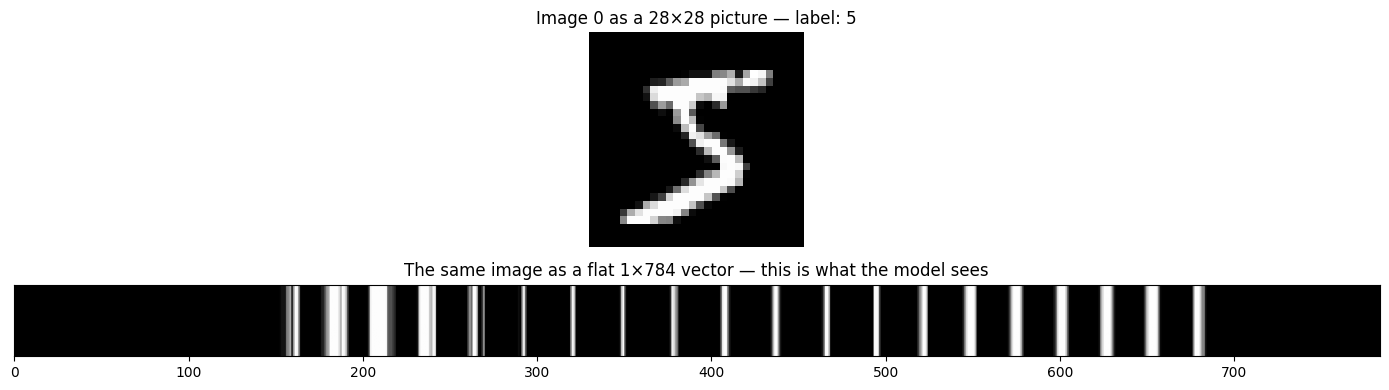

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 4), gridspec_kw={"height_ratios": [3, 1]})
axes[0].imshow(X_train[0].view(28, 28), cmap="gray")
axes[0].set_title(f"Image 0 as a 28×28 picture — label: {y_train[0].item()}")
axes[0].axis("off")
axes[1].imshow(X_train[0].view(1, 784), cmap="gray", aspect="auto")
axes[1].set_title("The same image as a flat 1×784 vector — this is what the model sees")
axes[1].set_yticks([])
plt.tight_layout(); plt.show()

## 1.4 — Batching: `TensorDataset` and `DataLoader` 🧩

💡 128 is a sensible batch size. Shuffle train, don't shuffle test.

In [ ]:
# 🧩 FILL IN THE BLANKS

train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

print("Training batches:", len(train_loader))
print("Test batches:    ", len(test_loader))

xb, yb = next(iter(train_loader))
print("\nOne batch of images:", xb.shape)
print("One batch of labels:", yb.shape)
print("Labels in this batch:", yb[:16].tolist())

Training batches: 469
Test batches:     79

One batch of images: torch.Size([128, 784])
One batch of labels: torch.Size([128])
Labels in this batch: [1, 2, 8, 5, 2, 6, 9, 9, 9, 4, 0, 3, 9, 9, 5, 6]


✅ 469 training batches • `xb` is `[128, 784]` • `yb` is `[128]`

---
## 1.5 — One layer 🧩

In [ ]:
# 🧩 784 pixels in, 10 digit-scores out

single_layer = nn.Linear(784,10)

print("Weight shape:", single_layer.weight.shape)
print("Bias shape:  ", single_layer.bias.shape)
print("Total parameters:", sum(p.numel() for p in single_layer.parameters()))

Weight shape: torch.Size([10, 784])
Bias shape:   torch.Size([10])
Total parameters: 7850


✅ weight `[10, 784]` • bias `[10]` • **7850** parameters

In [ ]:
out = single_layer(xb)

print("Input shape: ", xb.shape)
print("Output shape:", out.shape)
print("\nRaw scores for image 0:\n", out[0])
print("\nModel's guess:", out[0].argmax().item(), " | Actual label:", yb[0].item())

Input shape:  torch.Size([128, 784])
Output shape: torch.Size([128, 10])

Raw scores for image 0:
 tensor([-0.1215, -0.3348,  0.2435,  0.2003, -0.2909, -0.0312,  0.1894,  0.1724,
         0.1156,  0.2130], grad_fn=<SelectBackward0>)

Model's guess: 2  | Actual label: 1


## 1.6 — Stack layers into a network 🧩

`784 → Linear → 128 → ReLU → Linear → 10`

In [ ]:
# 🧩 FILL IN THE BLANKS

model = nn.Sequential(
    nn.Linear(784,128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

print(model)
print("\nTotal parameters:", sum(p.numel() for p in model.parameters()))
print("Output shape:", model(xb).shape)

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 101770
Output shape: torch.Size([128, 10])


✅ **101,770** parameters • output `[128, 10]`

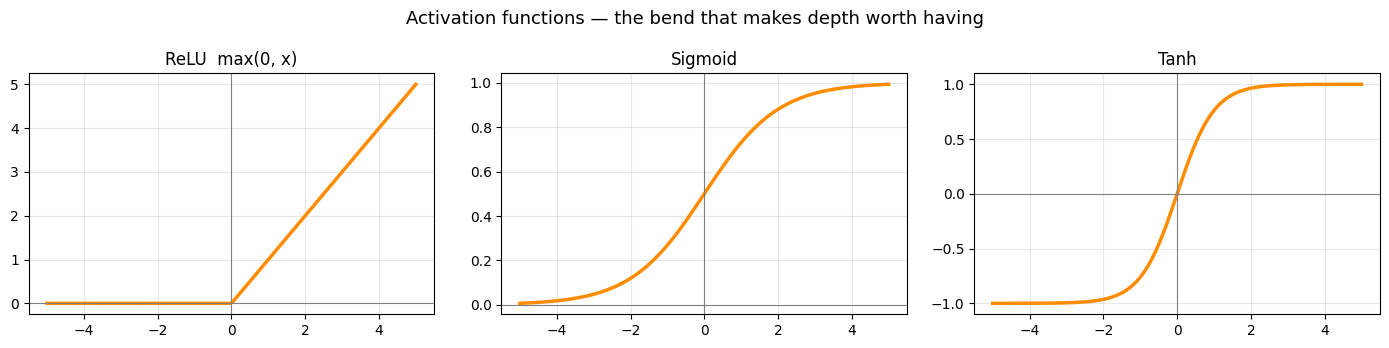

In [ ]:
x = torch.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, (name, fn) in zip(axes, [("ReLU  max(0, x)", torch.relu),
                                 ("Sigmoid", torch.sigmoid),
                                 ("Tanh", torch.tanh)]):
    ax.plot(x, fn(x), linewidth=2.5, color="darkorange")
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(name); ax.grid(alpha=0.3)
plt.suptitle("Activation functions — the bend that makes depth worth having", fontsize=13)
plt.tight_layout(); plt.show()

## 1.7 — The loss function 🧩

💡 Multi-class classification → cross-entropy.

In [ ]:
# 🧩 FILL IN THE BLANK

criterion = nn.CrossEntropyLoss()

preds = model(xb)
loss = criterion(preds, yb)

print("Loss on this batch:", loss.item())
print("Random guessing ≈ ln(10) =", np.log(10))

Loss on this batch: 2.302175283432007
Random guessing ≈ ln(10) = 2.302585092994046


✅ close to `2.3`

---
# ⭐ 1.8 — ONE training step, by hand

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
torch.set_printoptions(precision=6, sci_mode=False)

# --- WEIGHTS BEFORE ---
weights_before = model[0].weight.clone()
print("Weights BEFORE (first 5 of layer 1, neuron 0):")
print(weights_before[0][:5])

Weights BEFORE (first 5 of layer 1, neuron 0):
tensor([ 0.003141, -0.019464, -0.008890, -0.029141, -0.033453],
       grad_fn=<SliceBackward0>)


In [ ]:
# ============================================================
#   THE FIVE LINES THAT TRAIN A NEURAL NETWORK
# ============================================================

optimizer.zero_grad()         # 1. clear old gradients
preds = model(xb)             # 2. forward pass
loss = criterion(preds, yb)   # 3. how wrong are we
loss.backward()               # 4. compute gradients
optimizer.step()              # 5. update the weights

print("Loss for this step:", loss.item())

Loss for this step: 2.302175283432007


In [ ]:
# --- WEIGHTS AFTER ---
weights_after = model[0].weight.clone()

print("BEFORE:", weights_before[0][:5])
print("AFTER: ", weights_after[0][:5])
print("MOVED: ", (weights_after - weights_before)[0][:5])
print("\nWeights that changed:", (weights_after != weights_before).sum().item(),
      "out of", weights_before.numel())

BEFORE: tensor([ 0.003141, -0.019464, -0.008890, -0.029141, -0.033453],
       grad_fn=<SliceBackward0>)
AFTER:  tensor([ 0.003141, -0.019464, -0.008890, -0.029141, -0.033453],
       grad_fn=<SliceBackward0>)
MOVED:  tensor([0., 0., 0., 0., 0.], grad_fn=<SliceBackward0>)

Weights that changed: 61258 out of 100352


# 🎉 The numbers are different. The model just learned something.

❓ A few thousand weights did **not** move. Why not?

In [ ]:
new_loss = criterion(model(xb), yb)

print("Loss BEFORE the step:", loss.item())
print("Loss AFTER  the step:", new_loss.item())
print("Improvement:         ", loss.item() - new_loss.item())

Loss BEFORE the step: 2.302175283432007
Loss AFTER  the step: 2.2203986644744873
Improvement:          0.08177661895751953


### 🔬 50 steps on a single batch

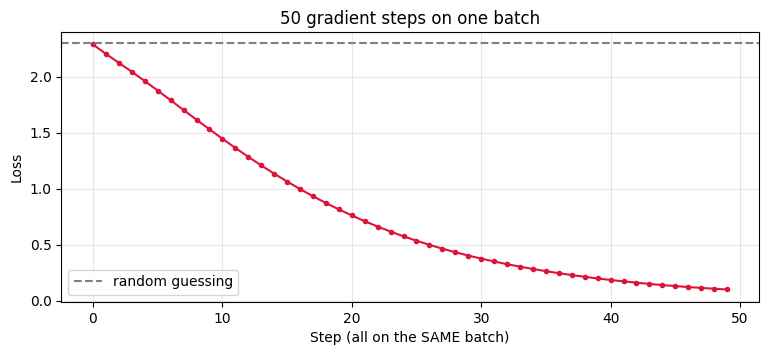

Loss went from 2.2860 → 0.0988


In [ ]:
mini_model = nn.Sequential(nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
mini_optim = torch.optim.Adam(mini_model.parameters(), lr=1e-3)   # 🔬 try 1e-1 and 1e-5

losses = []
for step in range(50):
    mini_optim.zero_grad()
    l = criterion(mini_model(xb), yb)
    l.backward()
    mini_optim.step()
    losses.append(l.item())

plt.figure(figsize=(9, 3.5))
plt.plot(losses, marker="o", markersize=3, color="crimson")
plt.axhline(np.log(10), color="gray", linestyle="--", label="random guessing")
plt.xlabel("Step (all on the SAME batch)"); plt.ylabel("Loss")
plt.title("50 gradient steps on one batch"); plt.legend(); plt.grid(alpha=0.3); plt.show()

print(f"Loss went from {losses[0]:.4f} → {losses[-1]:.4f}")

---
## 1.9 — One epoch = loop over all the batches 🧩

💡 The same five lines, from memory: `zero_grad` → forward → loss → `backward` → `step`.

In [ ]:
# 🧩 FILL IN THE FIVE LINES

model = nn.Sequential(nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

running_loss = 0.0
batch_losses = []

for i, (xb, yb) in enumerate(train_loader):
    xb, yb = xb.to(device), yb.to(device)

    optimizer.zero_grad()         # 1. clear old gradients
    preds = model(xb)             # 2. forward pass
    loss = criterion(preds, yb)   # 3. how wrong are we
    loss.backward()               # 4. compute gradients
    optimizer.step()              # 5. update the weights

    running_loss += loss.item()
    batch_losses.append(loss.item())

    if i % 100 == 0:
        print(f"  batch {i:3d}/{len(train_loader)} | loss: {loss.item():.4f}")

print(f"\nAverage loss this epoch: {running_loss / len(train_loader):.4f}")

  batch   0/469 | loss: 2.3088
  batch 100/469 | loss: 0.4410
  batch 200/469 | loss: 0.3434
  batch 300/469 | loss: 0.2737
  batch 400/469 | loss: 0.2726

Average loss this epoch: 0.4165


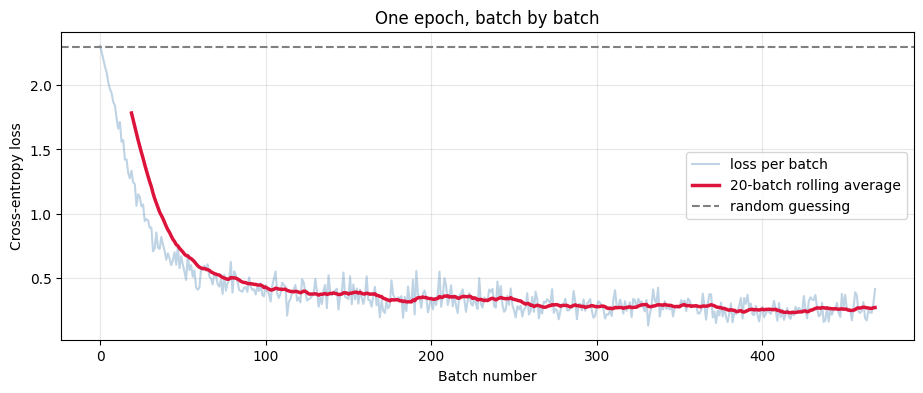

In [ ]:
plt.figure(figsize=(11, 4))
plt.plot(batch_losses, alpha=0.35, color="steelblue", label="loss per batch")

window = 20
smooth = np.convolve(batch_losses, np.ones(window) / window, mode="valid")
plt.plot(range(window - 1, len(batch_losses)), smooth,
         color="crimson", linewidth=2.5, label=f"{window}-batch rolling average")

plt.axhline(np.log(10), color="gray", linestyle="--", label="random guessing")
plt.xlabel("Batch number"); plt.ylabel("Cross-entropy loss")
plt.title("One epoch, batch by batch"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 1.10 — Measure accuracy 🧩

💡 Given a `[batch, 10]` tensor, which dim holds the class scores?

In [ ]:
# 🧩 FILL IN THE BLANKS

model.eval()
correct, total = 0, 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(dim=____)
        correct += (preds == yb).____().item()
        total   += yb.size(0)

print(f"Test accuracy: {correct}/{total} = {correct/total:.4f}")
print("Baseline (always guess the most common digit): 0.1135")

# 🎉 ~95% on 10,000 unseen digits, after one epoch.

## 1.11 — Wrap it in functions

In [ ]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total


def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_acc": []}
    print(f"Accuracy BEFORE training: {evaluate(model, val_loader):.4f}\n")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()          # 1
            preds = model(xb)              # 2
            loss = criterion(preds, yb)    # 3
            loss.backward()                # 4
            optimizer.step()               # 5

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        val_acc = evaluate(model, val_loader)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch+1:2d}/{epochs} | loss: {train_loss:.4f} | val acc: {val_acc:.4f}")

    print(f"\nAccuracy AFTER training: {evaluate(model, val_loader):.4f}")
    return model, history


def plot_history(history, title="Training curves"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    axes[0].plot(epochs, history["train_loss"], marker="o", color="crimson")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Training loss")
    axes[0].set_title("Loss — should go DOWN"); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, history["val_acc"], marker="o", color="seagreen")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation accuracy")
    axes[1].set_title("Accuracy — should go UP"); axes[1].grid(alpha=0.3)
    plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()

print("✅ evaluate(), train_model(), plot_history() ready.")

## 1.12 — Wrap the model in a class 🧩

💡 `forward` should push `x` through `self.net`.

In [ ]:
# 🧩 FILL IN THE BLANKS

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(____, ____),
            nn.ReLU(),
            nn.Linear(____, ____)
        )

    def forward(self, x):
        return ____


demo = MLP(input_dim=784, hidden_dim=128, output_dim=10)
print(demo)
print("\nParameters:", sum(p.numel() for p in demo.parameters()))
print("Output on a real batch:", demo(xb.cpu()).shape)

✅ **101,770** parameters • output `[128, 10]` — identical to the `Sequential` version

## 1.13 — Train it

In [ ]:
mnist_model = MLP(input_dim=784, hidden_dim=128, output_dim=10)
mnist_model, mnist_history = train_model(mnist_model, train_loader, test_loader, epochs=5)

In [ ]:
plot_history(mnist_history, "MNIST — 5 epochs")

✅ starts ~`0.10` (random) → ends ~`0.97–0.98`

## 1.14 — See the predictions

In [ ]:
mnist_model.eval()
sample_x = X_test[:10].to(device)
sample_y = y_test[:10]

with torch.no_grad():
    preds = mnist_model(sample_x).argmax(dim=1).cpu()

fig, axes = plt.subplots(1, 10, figsize=(18, 2.6))
for i, ax in enumerate(axes):
    ax.imshow(sample_x[i].cpu().view(28, 28), cmap="gray")
    ok = preds[i].item() == sample_y[i].item()
    ax.set_title(f"{preds[i].item()}", color="green" if ok else "red", fontsize=18)
    ax.axis("off")
plt.suptitle("Predictions (green = correct)", fontsize=13); plt.show()

print("Predicted:", preds.tolist())
print("Actual:   ", sample_y.tolist())

# 🎉 Random noise → a working digit recogniser, every line written by us.

## 1.15 — Where does it still get things wrong?

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

all_preds, all_true = [], []
mnist_model.eval()
with torch.no_grad():
    for xb_, yb_ in test_loader:
        all_preds.append(mnist_model(xb_.to(device)).argmax(dim=1).cpu())
        all_true.append(yb_)

all_preds = torch.cat(all_preds).numpy()
all_true  = torch.cat(all_true).numpy()
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion matrix"); plt.show()

off = cm.copy(); np.fill_diagonal(off, 0)
i, j = np.unravel_index(off.argmax(), off.shape)
print(f"Most common mistake: a true {i} predicted as {j}, {off[i, j]} times.")

## 1.16 — 🔬 Your turn

| Change | Val acc after 5 epochs | Observation |
|---|---|---|
| Baseline `hidden=128, lr=1e-3` | ~0.97 | |
| `hidden_dim=8` | | |
| `hidden_dim=512` | | |
| `lr=1e-1` | | |
| `lr=1e-5` | | |
| No ReLU | | |

In [ ]:
# 🔬 CHANGE THESE AND RE-RUN

HIDDEN_DIM = 128      # try 8, 32, 512
LEARNING_RATE = 1e-3  # try 1e-1, 1e-2, 1e-4, 1e-5
EPOCHS = 3

torch.manual_seed(42)
exp_model = MLP(input_dim=784, hidden_dim=HIDDEN_DIM, output_dim=10)
exp_model, exp_history = train_model(exp_model, train_loader, test_loader,
                                     epochs=EPOCHS, lr=LEARNING_RATE)
plot_history(exp_history, f"hidden={HIDDEN_DIM}, lr={LEARNING_RATE}")

### 🔬 Does ReLU actually matter?

In [ ]:
torch.manual_seed(42)
no_relu = nn.Sequential(nn.Linear(784, 128), nn.Linear(128, 10))   # 👈 no ReLU
no_relu, hist_no_relu = train_model(no_relu, train_loader, test_loader, epochs=3)

torch.manual_seed(42)
one_layer = nn.Sequential(nn.Linear(784, 10))
one_layer, hist_one = train_model(one_layer, train_loader, test_loader, epochs=3)

print("\n" + "=" * 55)
print(f"Two Linear layers, NO ReLU : {hist_no_relu['val_acc'][-1]:.4f}")
print(f"One Linear layer           : {hist_one['val_acc'][-1]:.4f}")
print(f"Two Linear layers + ReLU   : {exp_history['val_acc'][-1]:.4f}")
print("=" * 55)

❓ The no-ReLU net has 101,770 parameters; the single layer has 7,850. Why do they land in the same place?

---
# 🚢 Chapter 2 — Titanic

Same tools, messy data. **No new PyTorch from here — `MLP` and `train_model` are finished.**

## 2.1 — Load and look

In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid")

titanic = sns.load_dataset("titanic")
print("Shape:", titanic.shape)
titanic.head()

## 2.2 — Find the problems

In [ ]:
print("Missing values per column:")
print(titanic.isna().sum().sort_values(ascending=False).head(8))

print("\nColumn data types:")
print(titanic.dtypes.head(10))

print("\nSurvival balance:")
print(titanic["survived"].value_counts())
print(f"\nMajority-class baseline: {titanic['survived'].value_counts(normalize=True).max():.2%}")

In [ ]:
missing = titanic.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(missing.index[::-1], missing.values[::-1], color="indianred", edgecolor="black")
axes[0].set_xlabel("Missing values"); axes[0].set_title("Which columns have holes?")
for i, v in enumerate(missing.values[::-1]):
    axes[0].text(v + 5, i, f"{v} ({v/len(titanic):.0%})", va="center")
sns.heatmap(titanic.isna(), cbar=False, cmap="Reds", yticklabels=False, ax=axes[1])
axes[1].set_title("Missing-value map (red = missing)")
plt.tight_layout(); plt.show()

## 2.3 — Pick columns and fill the holes

In [ ]:
df = titanic[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].copy()

print("Columns kept:", list(df.columns))
print("\nMissing per column:")
print(df.isna().sum())

### 📊 Mean or median?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(df["age"].dropna(), bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].axvline(df["age"].mean(),   color="crimson",   ls="--", lw=2, label=f"mean   = {df['age'].mean():.1f}")
axes[0].axvline(df["age"].median(), color="darkgreen", ls="-",  lw=2, label=f"median = {df['age'].median():.1f}")
axes[0].set_title("Age — mildly right-skewed"); axes[0].legend()

sns.histplot(df["fare"], bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].axvline(df["fare"].mean(),   color="crimson",   ls="--", lw=2, label=f"mean   = {df['fare'].mean():.1f}")
axes[1].axvline(df["fare"].median(), color="darkgreen", ls="-",  lw=2, label=f"median = {df['fare'].median():.1f}")
axes[1].set_title("Fare — severely right-skewed"); axes[1].legend()

plt.tight_layout(); plt.show()

print(f"AGE  → mean {df['age'].mean():.2f} | median {df['age'].median():.2f} | skew {df['age'].skew():.2f}")
print(f"FARE → mean {df['fare'].mean():.2f} | median {df['fare'].median():.2f} | skew {df['fare'].skew():.2f}")

In [ ]:
ages = df["age"].dropna().copy()
corrupted = ages.copy()
corrupted.iloc[0] = 5000        # one typo: a 5000-year-old passenger

print(f"{'':10} {'ORIGINAL':>10} {'AFTER TYPO':>12} {'CHANGE':>10}")
print(f"{'Mean:':10} {ages.mean():>10.2f} {corrupted.mean():>12.2f} {corrupted.mean()-ages.mean():>+10.2f}")
print(f"{'Median:':10} {ages.median():>10.2f} {corrupted.median():>12.2f} {corrupted.median()-ages.median():>+10.2f}")

In [ ]:
plt.figure(figsize=(6, 3.5))
sns.countplot(data=df, x="embarked", order=df["embarked"].value_counts().index,
              hue="embarked", palette="viridis", legend=False)
plt.title("Port of embarkation (2 values missing)")
plt.xlabel("C = Cherbourg, Q = Queenstown, S = Southampton")
plt.show()

print(df["embarked"].value_counts(dropna=False))
print("\nMode:", df["embarked"].mode()[0])

### 🧩 Fill the holes

💡 `.mode()` returns a Series (ties are possible), so index `[0]`.

In [ ]:
# 🧩 FILL IN THE BLANKS

print("Missing before:", df.isna().sum().sum())

df["age"]      = df["age"].fillna(df["age"].____())
df["embarked"] = df["embarked"].fillna(df["embarked"].____()[0])

print("Missing after: ", df.isna().sum().sum())
print("\nAge fill value:     ", titanic["age"].median())
print("Embarked fill value:", titanic["embarked"].mode()[0])
df.head()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
sns.histplot(titanic["age"].dropna(), bins=40, ax=axes[0], color="steelblue")
axes[0].set_title(f"BEFORE filling ({titanic['age'].notna().sum()} real ages)"); axes[0].set_xlabel("Age")
sns.histplot(df["age"], bins=40, ax=axes[1], color="seagreen")
axes[1].axvline(titanic["age"].median(), color="crimson", ls="--", label="the spike we created")
axes[1].set_title("AFTER filling (891 ages)"); axes[1].set_xlabel("Age"); axes[1].legend()
plt.tight_layout(); plt.show()

print("Std before filling:", round(titanic["age"].std(), 3))
print("Std after filling: ", round(df["age"].std(), 3))

## 2.4 — Turn text into numbers 🧩

In [ ]:
print(df[["sex", "embarked"]].head())
print("\nsex:     ", df["sex"].unique())
print("embarked:", df["embarked"].unique())

In [ ]:
# 🧩 FILL IN THE BLANKS

df["sex"] = df["sex"].map({"male": ____, "female": ____})

df = pd.get_dummies(df, columns=[____], drop_first=True, dtype=int)

print(df.head())
print("\nColumns now:", list(df.columns))
print("All numeric?", df.dtypes.apply(lambda t: np.issubdtype(t, np.number)).all())

✅ `survived, pclass, sex, age, sibsp, parch, fare, embarked_Q, embarked_S`

In [ ]:
plot_df = titanic.copy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ["sex", "pclass", "embarked"],
                          ["by sex", "by class", "by port"]):
    sns.barplot(data=plot_df, x=col, y="survived", ax=ax, hue=col,
                palette="Set2", legend=False, errorbar=None)
    ax.set_title(f"Survival rate {title}"); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

print(plot_df.groupby("sex", observed=True)["survived"].mean().round(3))

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature correlations"); plt.show()

## 2.5 — Split into X / y, train / test 🧩

⚠️ Features must be `float32`, labels must be `int64`.

In [ ]:
# 🧩 FILL IN THE BLANKS

from sklearn.model_selection import train_test_split

X = df.drop(columns=[____]).values.astype("float32")
y = df[____].values.astype("int64")

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=____, random_state=42, stratify=y
)

print("\nTrain:", X_train.shape, "| Test:", X_test.shape)
print(f"Survival rate — all: {y.mean():.3f} | train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

✅ `X` is `(891, 8)` • train `(712, 8)` • test `(179, 8)` • all three survival rates match

## 2.6 — Put everything on the same scale 🧩

In [ ]:
feature_names = list(df.drop(columns=["survived"]).columns)

plt.figure(figsize=(11, 4))
plt.boxplot([X_train[:, i] for i in range(X_train.shape[1])])
plt.xticks(range(1, len(feature_names) + 1), feature_names, rotation=30)
plt.title("BEFORE scaling — 'fare' dominates everything"); plt.ylabel("Raw value")
plt.show()

print("Means:", X_train.mean(axis=0).round(2))
print("Stds: ", X_train.std(axis=0).round(2))

$$z = \frac{x - \mu}{\sigma}$$

⚠️ **`fit_transform` on train. `transform` only on test.**

In [ ]:
# 🧩 FILL IN THE BLANKS

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.____(X_train).astype("float32")
X_test  = scaler.____(X_test).astype("float32")

print("Means:", X_train.mean(axis=0).round(2))
print("Stds: ", X_train.std(axis=0).round(2))
print("\nμ learned:", scaler.mean_.round(2))
print("σ learned:", np.sqrt(scaler.var_).round(2))

In [ ]:
plt.figure(figsize=(11, 4))
plt.boxplot([X_train[:, i] for i in range(X_train.shape[1])])
plt.xticks(range(1, len(feature_names) + 1), feature_names, rotation=30)
plt.axhline(0, color="crimson", ls="--", lw=1)
plt.title("AFTER scaling — every feature speaks the same language")
plt.ylabel("Standardised value"); plt.show()

✅ all means ≈ `0`, all stds ≈ `1`

## 2.7 — Into tensors — same pattern as Chapter 1

In [ ]:
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test)

print("Features:", X_train_t.dtype, " Labels:", y_train_t.dtype)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32)

xb, yb = next(iter(train_loader))
print("\nBatch:", xb.shape, yb.shape)
print("Batches per epoch:", len(train_loader), "(MNIST had 469)")

## 2.8 — Train, with zero new code 🧩

💡 Don't hard-code the input size — read it off the data.

In [ ]:
# 🧩 FILL IN THE BLANKS

titanic_model = MLP(input_dim=____, hidden_dim=16, output_dim=____)
print(titanic_model)
print()

titanic_model, titanic_history = train_model(
    titanic_model, train_loader, test_loader, epochs=30, lr=1e-3
)

In [ ]:
plot_history(titanic_history, "Titanic — 30 epochs")

# 🎉 Same `MLP`, same `train_model` — not one line rewritten.

✅ starts ~0.4–0.6 → settles ~**0.78–0.82** (baseline was 61.6%)

❓ Why 30 epochs here, when MNIST needed 5?

## 2.9 — Predict on a made-up passenger 🧩

In [ ]:
print("Feature order the model expects:")
for i, name in enumerate(feature_names):
    print(f"  {i}: {name}")

In [ ]:
# 🧩 FILL IN THE BLANKS
#     order: pclass, sex(0=m,1=f), age, sibsp, parch, fare, embarked_Q, embarked_S

p1 = np.array([[1, 1, 25, 0, 0, 100, 0, 1]], dtype="float32")   # 1st class woman, 25
p2 = np.array([[3, 0, 40, 0, 0,   8, 0, 1]], dtype="float32")   # 3rd class man, 40

titanic_model.eval()
for name, p in [("1st class woman, age 25", p1),
                ("3rd class man, age 40  ", p2)]:
    p_scaled = torch.tensor(scaler.____(p).astype("float32")).to(device)
    with torch.no_grad():
        logits = titanic_model(p_scaled)
        probs  = torch.____(logits, dim=1)
    print(f"{name} → scores {logits[0].cpu().numpy().round(2)} "
          f"→ survival probability: {probs[0][1].item():.1%}")

### 🔬 Build your own passenger

In [ ]:
my_passenger = {
    "pclass":     3,     # 1, 2 or 3
    "sex":        0,     # 0 = male, 1 = female
    "age":        30,
    "sibsp":      0,
    "parch":      0,
    "fare":       10,
    "embarked_Q": 0,
    "embarked_S": 1,     # both 0 = Cherbourg
}

vec = np.array([[my_passenger[n] for n in feature_names]], dtype="float32")
vec_scaled = torch.tensor(scaler.transform(vec).astype("float32")).to(device)

titanic_model.eval()
with torch.no_grad():
    prob = torch.softmax(titanic_model(vec_scaled), dim=1)[0][1].item()

print(f"Survival probability: {prob:.1%}")
print("  " + "█" * int(prob * 50) + "░" * (50 - int(prob * 50)))

### 🔬 Which feature is the model leaning on?

In [ ]:
base = np.array([[3, 0, 30, 0, 0, 10, 0, 1]], dtype="float32")

def survival_prob(vec):
    v = torch.tensor(scaler.transform(vec).astype("float32")).to(device)
    with torch.no_grad():
        return torch.softmax(titanic_model(v), dim=1)[0][1].item()

base_prob = survival_prob(base)
variations = {
    "baseline (3rd class man, 30)": base.copy(),
    "→ make it a woman":            np.array([[3, 1, 30, 0, 0,  10, 0, 1]], dtype="float32"),
    "→ make it 1st class":          np.array([[1, 0, 30, 0, 0,  10, 0, 1]], dtype="float32"),
    "→ make it a child (age 5)":    np.array([[3, 0,  5, 0, 0,  10, 0, 1]], dtype="float32"),
    "→ pay a £100 fare":            np.array([[3, 0, 30, 0, 0, 100, 0, 1]], dtype="float32"),
}
names = list(variations.keys())
probs = [survival_prob(v) for v in variations.values()]

plt.figure(figsize=(9, 4))
colors = ["gray"] + ["seagreen" if p > base_prob else "indianred" for p in probs[1:]]
plt.barh(names[::-1], probs[::-1], color=colors[::-1], edgecolor="black")
plt.axvline(base_prob, color="black", ls="--", lw=1)
plt.xlim(0, 1); plt.xlabel("Predicted survival probability")
plt.title("Change one thing at a time"); plt.tight_layout(); plt.show()

for n, p in zip(names, probs):
    print(f"{n:32} {p:6.1%}")

### 🔬 More to try

| Experiment | Change | Look for |
|---|---|---|
| Overfit it | `hidden_dim=256`, `epochs=200` | loss falls, val acc stalls or drops |
| Skip the scaler | re-run 2.7 unscaled | how much worse, how much slower |
| Drop `sex` | remove before 2.5 | how much accuracy lived in one column |
| Add a feature | `df["family_size"] = df["sibsp"] + df["parch"] + 1` | does combining help? |
| Fill age with the mean | change 2.3 | does it matter here? |

---
# 🏁 Chapter 3 — Wrap-up

| | **MNIST** | **Titanic** |
|---|---|---|
| Input | 28×28 images | mixed table |
| Rows | 60,000 | 891 |
| Prep | flatten, ÷255 | fill NaNs, encode, scale, split |
| Model | `MLP(784, 128, 10)` | `MLP(8, 16, 2)` |
| Training | `train_model(...)` | `train_model(...)` ← identical |
| Result | ~97% (baseline 11%) | ~80% (baseline 62%) |

### 🔑 The five lines

```python
optimizer.zero_grad()        # clear old gradients
preds = model(xb)            # forward pass
loss = criterion(preds, yb)  # how wrong are we
loss.backward()              # compute gradients
optimizer.step()             # update the weights
```

### 🐛 Errors you can now read

| Error | Fix |
|---|---|
| `Expected all tensors to be on the same device` | `.to(device)` on both |
| `expected scalar type Long but found Float` | labels → `int64` |
| `mat1 and mat2 shapes cannot be multiplied` | print `.shape` at every step |
| loss becomes `nan` | check `isna().sum()`, lower the lr |
| loss won't move | forgot `optimizer.step()`, or lr too small |

### 📝 Homework

1. Swap `datasets.MNIST` for `datasets.FashionMNIST` in 1.1 and re-run Chapter 1. Accuracy will be lower — write two sentences on why.
2. Run any two experiments from 2.9. Record before/after accuracy and one sentence each.
3. From memory, on paper: the five lines, in order, one line of explanation each.